In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
consumption_df = pd.read_parquet(r"..\data\processed\consumption.parquet")

In [3]:
consumption_df.head(2)

,date,time,consumption
0,2018-01-01 00:00:00,00:00,27412.81
1,2018-01-01 01:00:00,01:00,26324.39


In [4]:
consumption_df.drop("time", axis=1, inplace=True)
consumption_df.head(2)

,date,consumption
0,2018-01-01 00:00:00,27412.81
1,2018-01-01 01:00:00,26324.39


In [6]:
# Hour
consumption_df["hour_sin"] = np.sin(2 * np.pi * consumption_df["date"].dt.hour/24)
consumption_df["hour_cos"] = np.cos(2 * np.pi * consumption_df["date"].dt.hour/24)

# Day of Week
consumption_df["day_sin"] = np.sin(2 * np.pi * consumption_df["date"].dt.dayofweek/7)
consumption_df["day_cos"] = np.cos(2 * np.pi * consumption_df["date"].dt.dayofweek/7)

# Month
consumption_df["month_sin"] = np.sin(2 * np.pi * consumption_df["date"].dt.month/12)
consumption_df["month_cos"] = np.cos(2 * np.pi * consumption_df["date"].dt.month/12)

In [7]:
consumption_df.head()

,date,consumption,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,2018-01-01 00:00:00,27412.81,0.000000,1.000000,0.0,1.0,0.5,0.866025
1,2018-01-01 01:00:00,26324.39,0.258819,0.965926,0.0,1.0,0.5,0.866025
2,2018-01-01 02:00:00,24635.32,0.500000,0.866025,0.0,1.0,0.5,0.866025
3,2018-01-01 03:00:00,23872.12,0.707107,0.707107,0.0,1.0,0.5,0.866025
4,2018-01-01 04:00:00,23194.89,0.866025,0.500000,0.0,1.0,0.5,0.866025


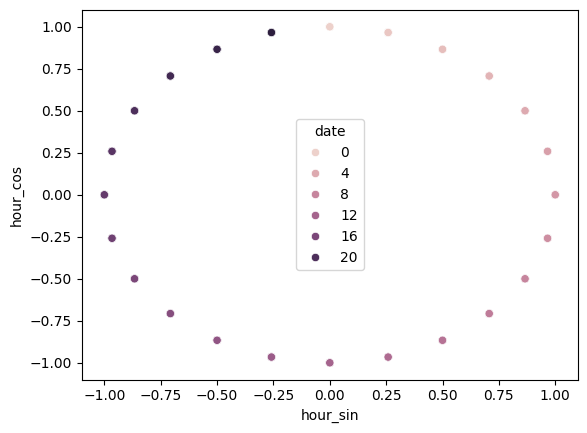

In [8]:
sns.scatterplot(x=consumption_df.hour_sin, y=consumption_df.hour_cos, hue=consumption_df.date.dt.hour)
plt.show()

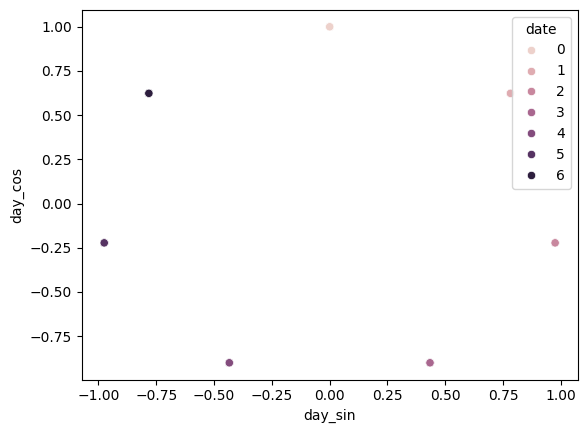

In [9]:
sns.scatterplot(x=consumption_df.day_sin, y=consumption_df.day_cos, hue=consumption_df.date.dt.dayofweek)
plt.show()

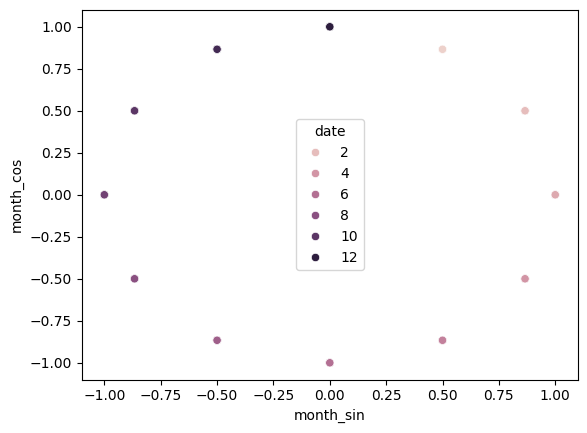

In [10]:
sns.scatterplot(x=consumption_df.month_sin, y=consumption_df.month_cos, hue=consumption_df.date.dt.month)
plt.show()

In [11]:
consumption_df.columns

Index(['date', 'consumption', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
       'month_sin', 'month_cos'],
      dtype='object')

In [12]:
processed_dir = "../data/processed"

In [13]:
train_df = consumption_df[(consumption_df["date"] >= "2018-01-01") & (consumption_df["date"] < "2024-01-01")].reset_index(drop=True)
val_df   = consumption_df[(consumption_df["date"] >= "2024-01-01") & (consumption_df["date"] < "2025-01-01")].reset_index(drop=True)
test_df  = consumption_df[(consumption_df["date"] >= "2025-01-01")].reset_index(drop=True)

In [14]:
print(f"{train_df.date.min()} - {train_df.date.max()}\n")
print(f"{val_df.date.min()} - {val_df.date.max()}\n")
print(f"{test_df.date.min()} - {test_df.date.max()}")

2018-01-01 00:00:00 - 2023-12-31 23:00:00

2024-01-01 00:00:00 - 2024-12-31 23:00:00

2025-01-01 00:00:00 - 2025-12-31 23:00:00


In [15]:
consumption_df.to_parquet(os.path.join(processed_dir, "consumption_fe.parquet"))
train_df.to_parquet(os.path.join(processed_dir, "train.parquet"))
val_df.to_parquet(os.path.join(processed_dir, "val.parquet"))
test_df.to_parquet(os.path.join(processed_dir, "test.parquet"))